# Tarea 3

**Instrucciones**

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a juancaros@udec.cl el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca)
- sk10: tiene interes por libros (1: siempre - 5: nunca)
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca)
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca)
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

# Pregunta 1

Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
from stepmix.stepmix import StepMix
import graphviz

In [256]:
url = "https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/junaeb3.csv"
df = pd.read_csv(url)
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31055 entries, 0 to 31054
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        31055 non-null  int64  
 1   edad        31055 non-null  int64  
 2   imce        31055 non-null  float64
 3   vive_padre  31055 non-null  int64  
 4   vive_madre  31055 non-null  int64  
 5   sk1         31055 non-null  int64  
 6   sk2         31055 non-null  int64  
 7   sk3         31055 non-null  int64  
 8   sk4         31055 non-null  int64  
 9   sk5         31055 non-null  int64  
 10  sk6         31055 non-null  int64  
 11  sk7         31055 non-null  int64  
 12  sk8         31055 non-null  int64  
 13  sk9         31055 non-null  int64  
 14  sk10        31055 non-null  int64  
 15  sk11        31055 non-null  int64  
 16  sk12        31055 non-null  int64  
 17  sk13        31055 non-null  int64  
 18  act_fisica  30051 non-null  float64
 19  area        31055 non-nul

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,...,31055.000000,31055.000000,31055.000000,31055.000000,31055.000000,30051.000000,31055.000000,30682.000000,31055.000000,31055.000000
mean,0.538979,82.589084,1.017787,0.720335,0.966511,1.114088,1.391177,1.262856,1.256352,1.268588,...,1.333666,1.853743,1.385349,1.502785,1.694735,2.556620,0.911544,13.069291,12.955756,0.092803
std,0.498486,4.360270,1.370552,0.449415,0.189671,0.394004,0.650190,0.585766,0.578266,0.564929,...,0.666009,0.941171,0.668783,0.799375,0.984946,1.068041,0.283961,3.338320,3.425190,0.943509
min,0.000000,62.000000,-5.020000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-1.000000
25%,0.000000,80.000000,0.120000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,12.000000,11.000000,-1.000000
50%,1.000000,81.000000,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,13.000000,13.000000,0.000000
75%,1.000000,82.000000,1.930000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,3.000000,1.000000,15.000000,14.000000,1.000000
max,1.000000,107.000000,5.040000,2.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000,22.000000,22.000000,1.000000


In [258]:
df = df.dropna()

# Pasamos variables float a enteras en caso de ser necesario
df['act_fisica'] = df['act_fisica'].astype(int)
df['educm'] = df['educm'].astype(int)

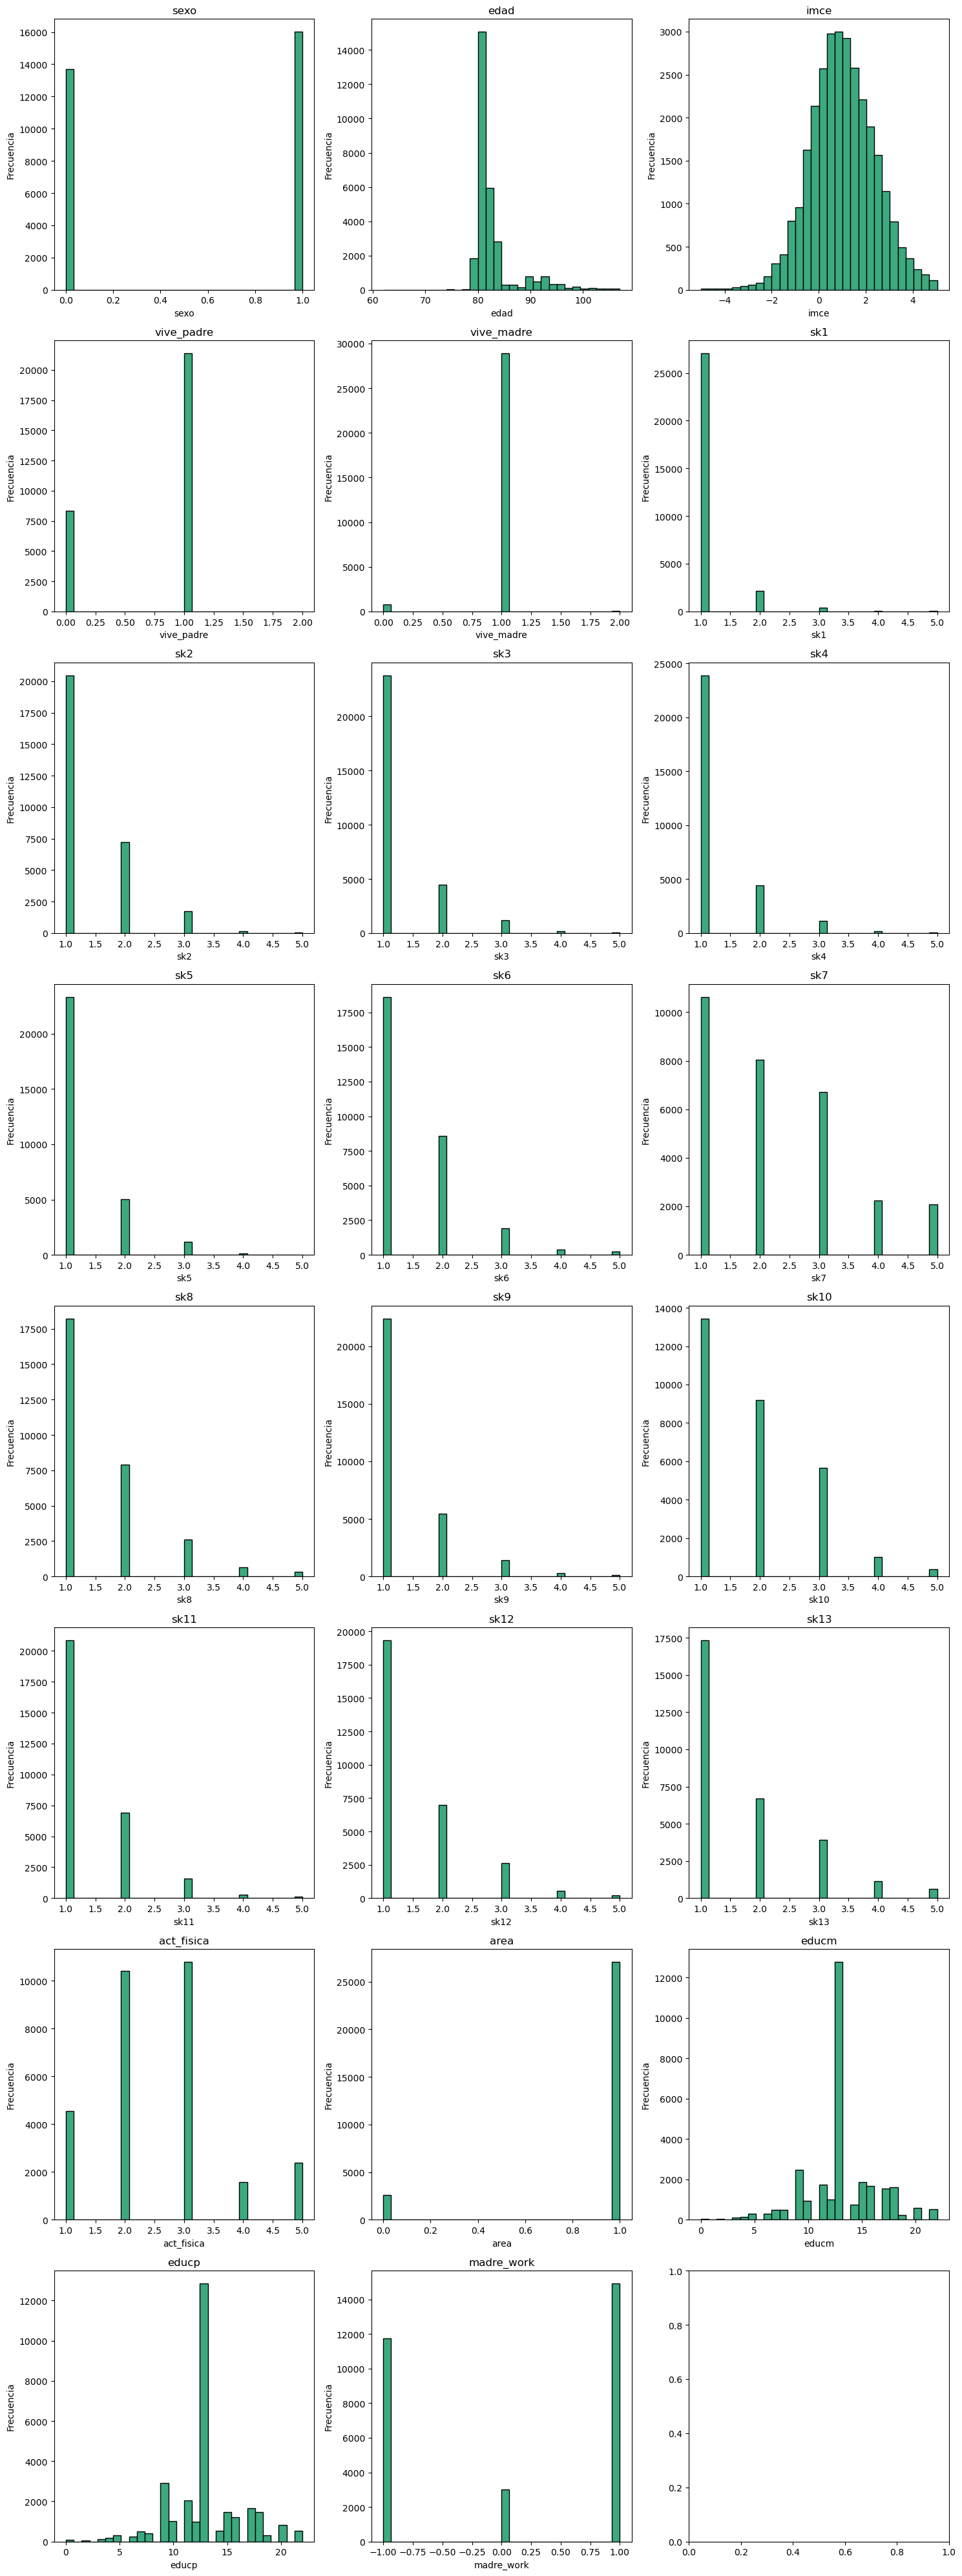

In [260]:
numerical_columns = df.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(df[column], bins=30, color='#3CA97E', edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()

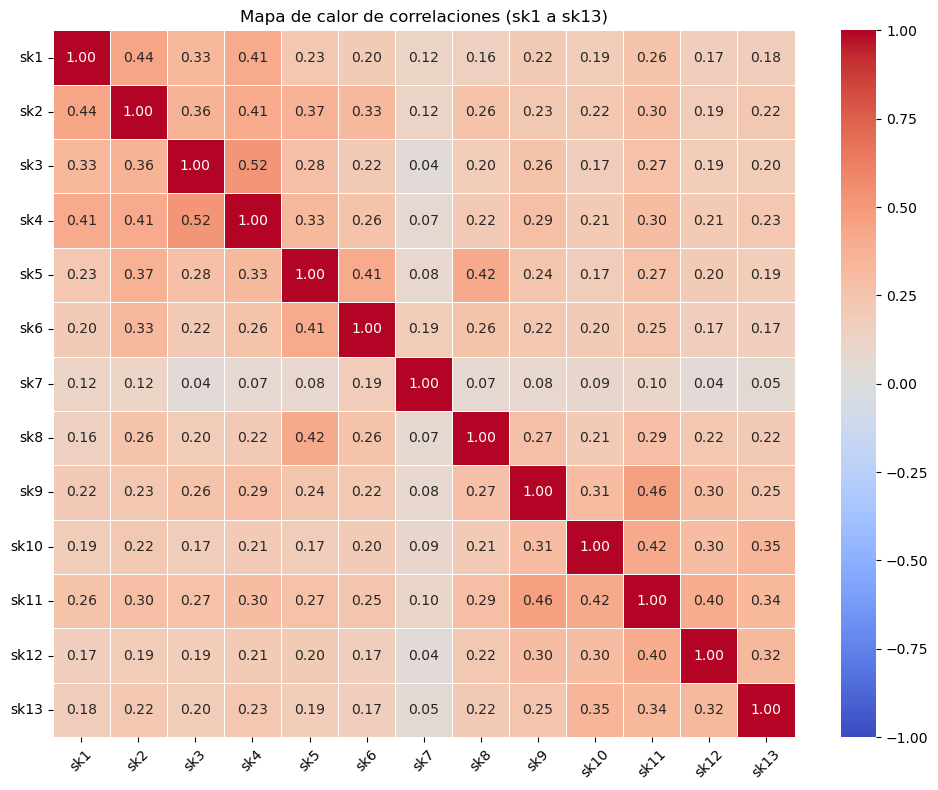

In [261]:
# 1. Seleccionar las columnas de interés (sk1 a sk13)
columnas_corr = df.loc[:, 'sk1':'sk13']  # Asume que las columnas están en orden

# 2. Calcular la matriz de correlación
matriz_corr = columnas_corr.corr()

# 3. Crear el mapa de calor
plt.figure(figsize=(10, 8))  # Tamaño del gráfico
sns.heatmap(
    matriz_corr,
    annot=True,      # Muestra los valores de correlación
    fmt=".2f",       # Formato de 2 decimales
    cmap="coolwarm", # Mapa de colores (rojo/azul)
    vmin=-1,         # Valor mínimo de correlación
    vmax=1,          # Valor máximo de correlación
    linewidths=0.5,  # Grosor de las líneas entre celdas
)

plt.title("Mapa de calor de correlaciones (sk1 a sk13)")
plt.xticks(rotation=45)  # Rotar etiquetas del eje X
plt.yticks(rotation=0)   # No rotar etiquetas del eje Y
plt.tight_layout()       # Ajustar layout
plt.show()

# Pregunta 2
A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

In [263]:
df1 = df.loc[:, 'sk1':'sk13']
df1 = df1.drop('sk7', axis=1) # eliminamos sk7, por el significado de la variable (agresividad)

fa = FactorAnalyzer(rotation='varimax').fit(df1)

np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.174841, 0.548195, 0.120534],
       [0.184364, 0.526839, 0.320694],
       [0.180408, 0.589673, 0.148862],
       [0.197244, 0.688252, 0.175895],
       [0.123231, 0.227225, 0.758978],
       [0.179168, 0.225624, 0.440862],
       [0.280362, 0.114328, 0.466153],
       [0.499531, 0.211997, 0.184684],
       [0.559231, 0.126959, 0.107675],
       [0.669339, 0.214191, 0.180514],
       [0.525805, 0.113139, 0.133111],
       [0.482427, 0.155489, 0.119697]])

In [264]:
fa.get_eigenvalues()[0]

array([4.003739, 1.347633, 1.089935, 0.802648, 0.743580, 0.706589,
       0.691043, 0.610450, 0.531272, 0.519068, 0.491722, 0.462321])

In [265]:
fa.get_communalities()

array([0.345616, 0.414394, 0.402421, 0.543535, 0.642865, 0.277366,
       0.308973, 0.328582, 0.340452, 0.526478, 0.306990, 0.271240])

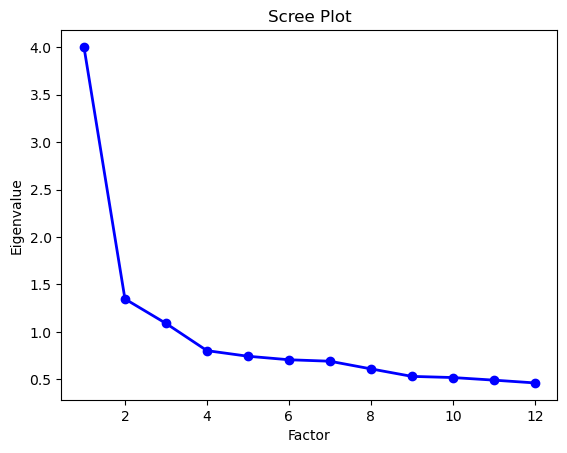

In [266]:
values = np.arange(1,13)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [267]:
fa.get_factor_variance()

(array([1.781394, 1.659008, 1.268511]),
 array([0.148450, 0.138251, 0.105709]),
 array([0.148450, 0.286700, 0.392409]))

In [269]:
print(semopy.efa.explore_cfa_model(df1, pval=0.05)) # No tiene relación

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta3 =~ sk11 + sk12 + sk13



# Respuesta 2

De los resultados obtenidos, logramos observar aplicando el criterio de los eigenvalues, los cuales tienen que ser mayor que uno para la selección de los factores, en este caso nos da 3 factores, ya que los valores mayores que uno son 4, 1.35 y 1.09, el cuarto factor tendría un eigenvalue de 0.8 estando por debajo del umbral del criterio.  

Luego también podemos observar la matriz de asociación de cada variable a cada factor, gracias a las cargas factoriales de (loadings), donde nos da que para el primer factor, las variables con más carga son, (sk9, sk10, sk11, sk12 y sk13), para el segundo factor son (sk1, sk2, sk3, sk4) y para el tercer y ultimo factor (sk5, sk6 y sk8).

Gracias a las comunalidades proporcianadas, observamos que dentro de las variables menos explicadas por los factores son, (sk6, sk8, sk11 y sk12), se consideran menos informativas, pero su valor no es tan bajo respecto al resto, por lo tanto no es de suma importancia. 


# Pregunta 3
Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

In [278]:
df = df.dropna().reset_index(drop=True)

factor_scores = fa.transform(df1)

factor_df = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])

factor_df['sexo'] = df['sexo'].values
factor_df['area'] = df['area'].values
factor_df['imce'] = df['imce'].values
factor_df['act_fisica'] = df['act_fisica'].values


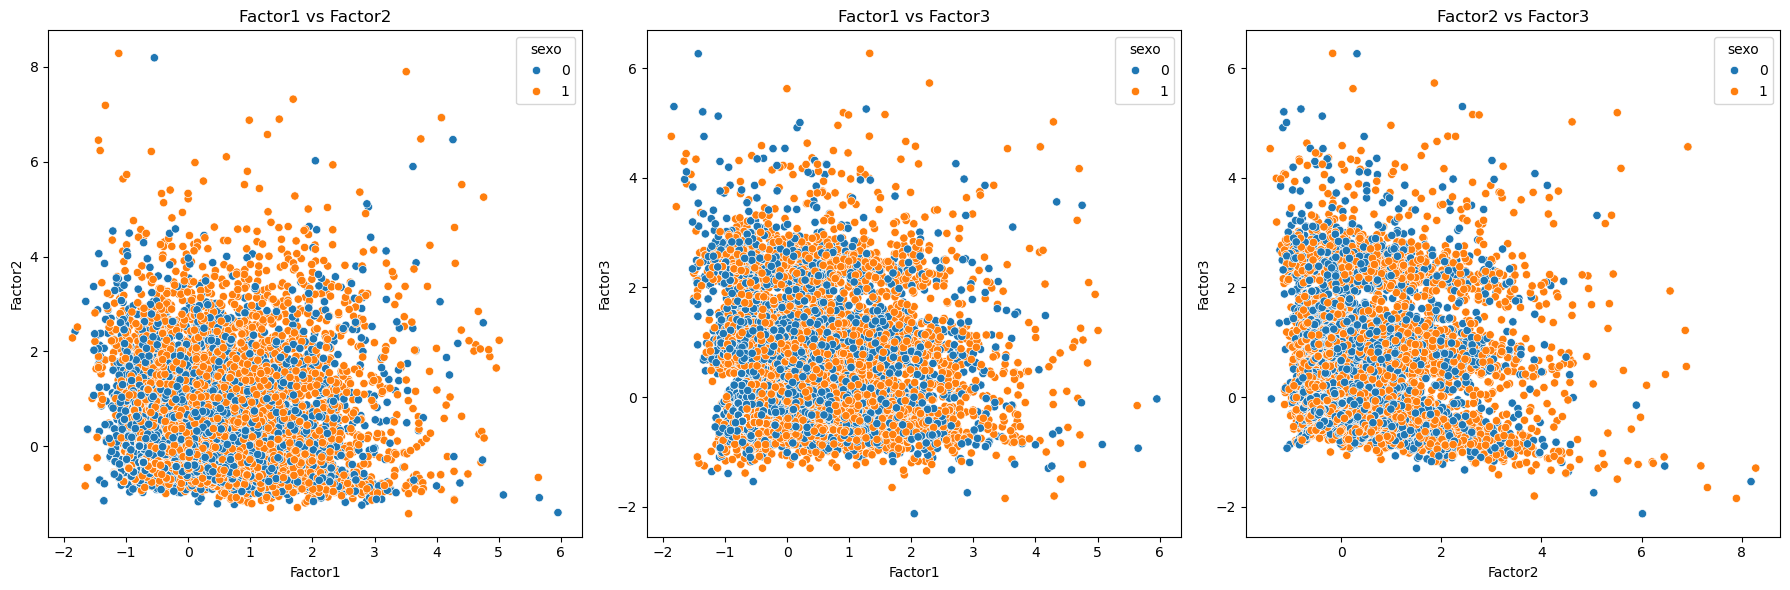

In [279]:
d = "sexo" 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

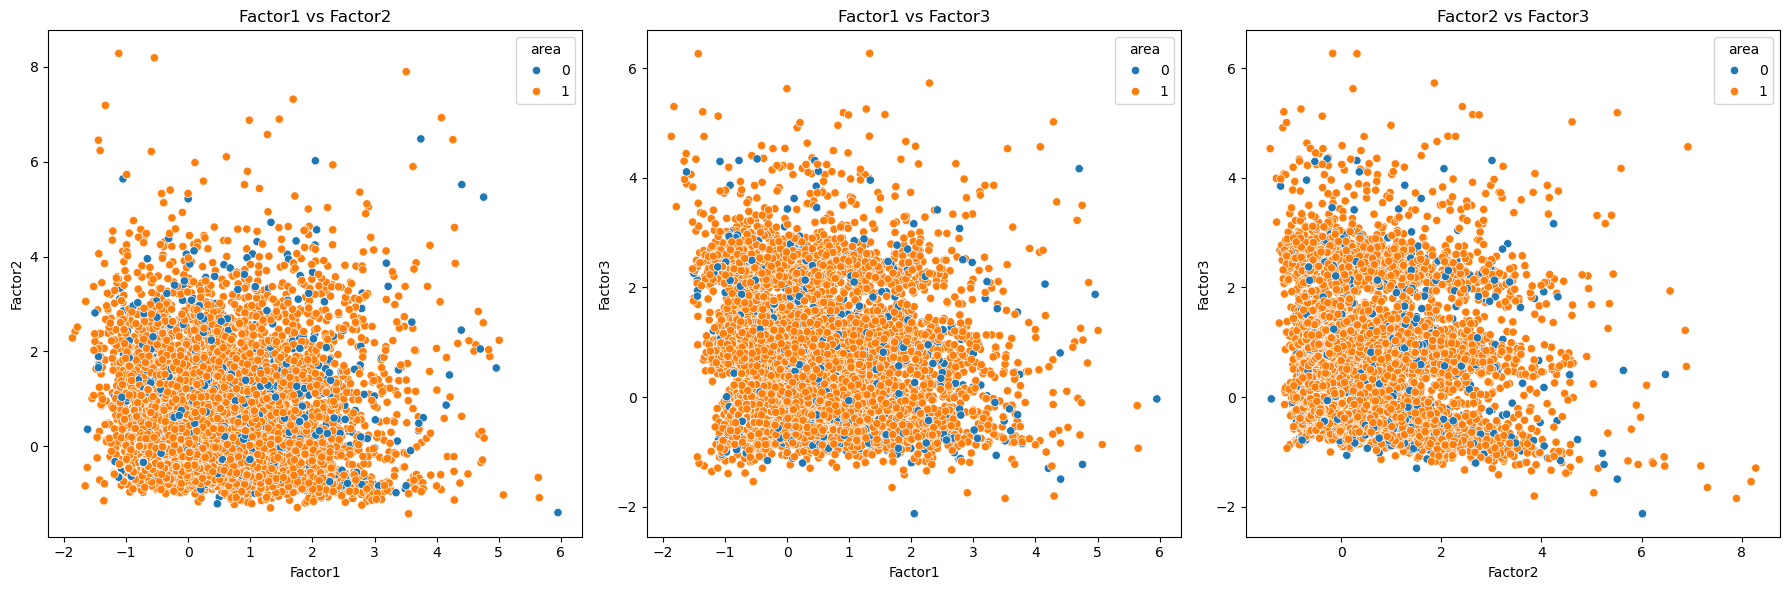

In [280]:
d = "area" 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

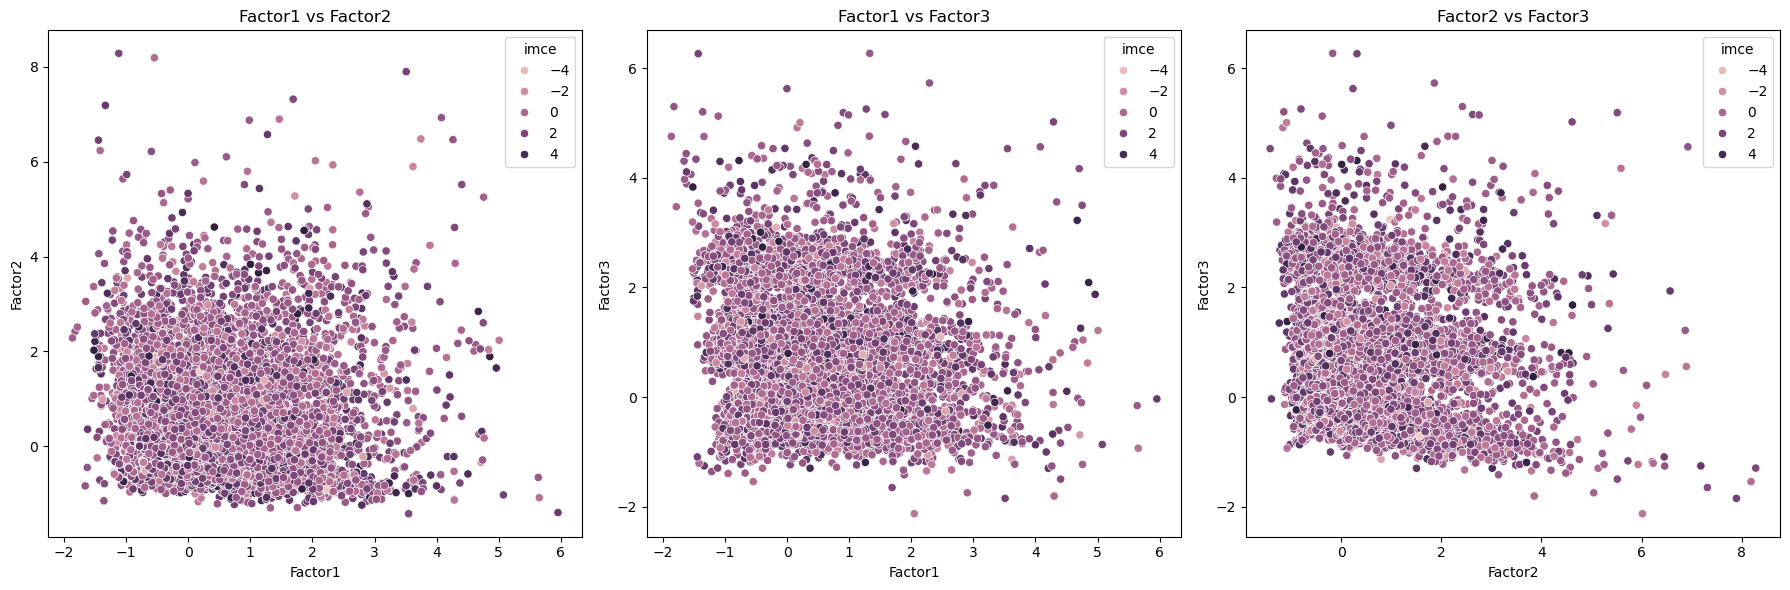

In [281]:
d = "imce" 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

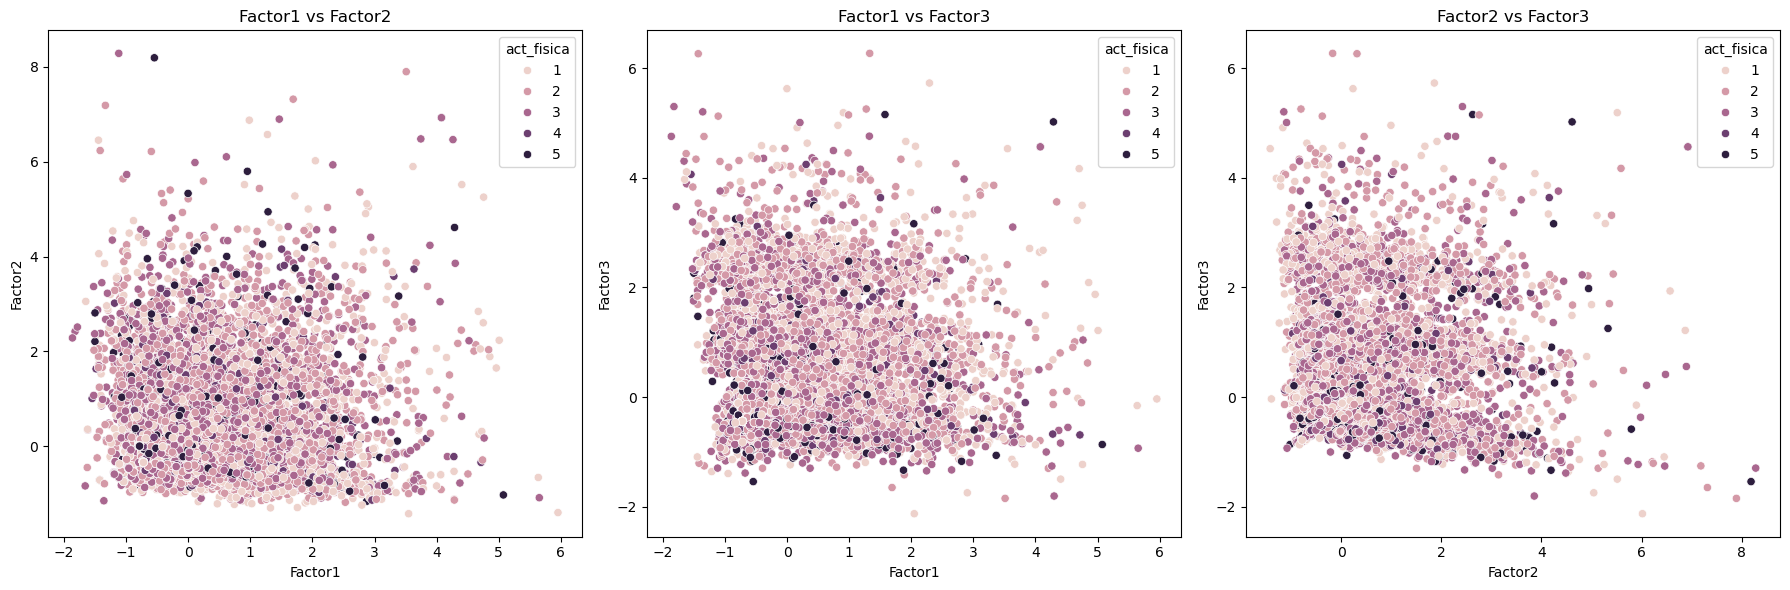

In [282]:
d = "act_fisica" 
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Factor1 vs Factor2
sns.scatterplot(data=factor_df, x='Factor1', y='Factor2', hue=d, ax=axs[0])
axs[0].set_title("Factor1 vs Factor2")
axs[0].set_xlabel("Factor1")
axs[0].set_ylabel("Factor2")

# Factor1 vs Factor3
sns.scatterplot(data=factor_df, x='Factor1', y='Factor3', hue=d, ax=axs[1])
axs[1].set_title("Factor1 vs Factor3")
axs[1].set_xlabel("Factor1")
axs[1].set_ylabel("Factor3")

# Factor2 vs Factor3
sns.scatterplot(data=factor_df, x='Factor2', y='Factor3', hue=d, ax=axs[2])
axs[2].set_title("Factor2 vs Factor3")
axs[2].set_xlabel("Factor2")
axs[2].set_ylabel("Factor3")

plt.tight_layout()
plt.show()

# Respuesta 3

Luego de observar los distintos gráficos, luego de ocupar la opción hue podemos concluir de los resultados que, entre las distintas comparaciones de factores existen diferencias significativas en la forma según se relacionan los distintos factores y la forma que tienen, también podemos ver una similitud de como se trabajan las distintas variables generales entre ellas.

Esto quiere decir que existe una validez discrimintante, por eso los factores parecen tener una capacidad para distinguir entre los distintos grupos con diferentes caracteristicas, lo que representa sus relaciones multivariadas y también las variables más influyentes.

# Pregunta 4
Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).

In [285]:
mod = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13       #Exploración Cognitiva y Creativa
eta2 =~ sk1 + sk2 + sk3 + sk4                 #Vinculación Afectiva y Emocional
eta3 =~ sk5 + sk6 + sk8                       #Cooperación y Sociabilidad
    """

model = semopy.Model(mod)
out=model.fit(df1) 
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.051 0.049 0.161 0.091 0.057 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [286]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.594425,-,-,-
1,sk10,~,eta1,1.348296,0.562596,0.01854,72.725071,0.0
2,sk11,~,eta1,1.247906,0.736003,0.014736,84.684717,0.0
3,sk12,~,eta1,1.097330,0.540702,0.015523,70.692694,0.0
4,sk13,~,eta1,1.273586,0.506374,0.018913,67.339241,0.0
5,sk1,~,eta2,1.000000,0.582652,-,-,-
6,sk2,~,eta2,1.876642,0.644548,0.023793,78.87212,0.0
7,sk3,~,eta2,1.646084,0.631816,0.021121,77.934883,0.0
8,sk4,~,eta2,1.845637,0.715782,0.022169,83.253688,0.0
9,sk5,~,eta3,1.000000,0.718118,-,-,-


In [287]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


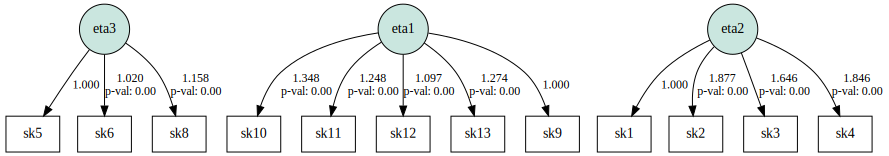

In [288]:
semopy.semplot(model, "model.png")

# Respuesta 4

Podemos observar que el análisis factorial confirmatorio (CFA) permitió la identificación de 3 factores latentes con cargas significativas en las respectivas variables, el primer factor de exploración cognitiva y creativa reflejando cargas significativas como por ejemplo en sk11, sugiriendo la capacidad de este factor para captar habilidades relacionadas con la curiosidad intelectual y la generacion de nuestras ideas.

A su vez el factor 2, vinculación afectiva y emocional, presento su mayor carga en sk4, indicando una fuerte dimensión emocional y de conexión interpersonal.

Por último, el factor 3, cooperación y sociabilidad, mostro una carga destacada en sk5, reflejando comportamientos sociales y habilidades de trabajo en equipo.

También logramos observar que los indices de ajustes (CFI = 0.948) y (RMSEA = 0.053) respaldan la validez de este modelo, confirmando lo adecuado que es para medir estas dimensiones en contextos aplicados, proporcionando una base sólida para evaluar y diferenciar estos 3 aspectos claves. 

# Pregunta 5
Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?


Fitting StepMix...


Initializations (n_init) : 100%|█████████████████████| 1/1 [00:00<00:00, 125.37it/s, max_LL=-5.15e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:07<00:00,  7.85s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]
C:\Users\Bryans\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:08<00:00,  8.01s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
C:\Users\Bryans\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:09<00:00,  9.12s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
C:\Users\Bryans\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:16<00:00, 16.26s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
C:\Users\Bryans\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


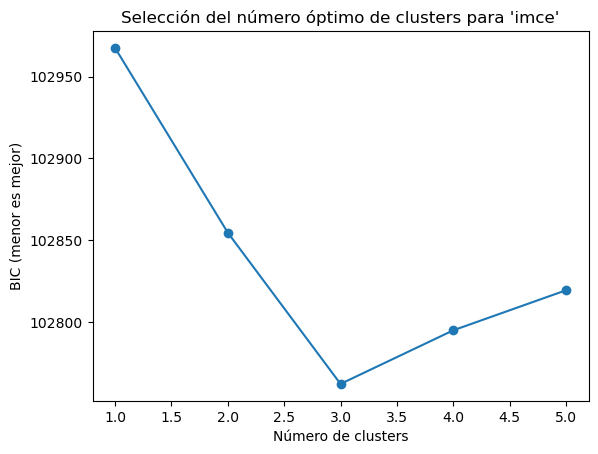

In [292]:
bic_scores = []
n_components_range = range(1, 6)  # Prueba de 1 a 5 clusters

for n_components in n_components_range:
    model = StepMix(
        n_components=n_components,
        measurement="continuous",  # Para datos numéricos (imce)
        random_state=42
    )
    # Usa df[["imce"]] (DataFrame 2D) en lugar de df["imce"] (Serie 1D)
    model.fit(df[["imce"]])  # Nota: doble corchete para DataFrame
    bic_scores.append(model.bic(df[["imce"]]))  # Mismo formato para el BIC

# Gráfico del BIC
import matplotlib.pyplot as plt
plt.plot(n_components_range, bic_scores, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("BIC (menor es mejor)")
plt.title("Selección del número óptimo de clusters para 'imce'")
plt.show()

In [294]:
df2=df[["imce"]]
model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(df2)

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:08<00:00,  8.34s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances imce            0.9629  1.4229  2.7533
          means       imce            0.5012  1.8813 -0.0576
    Class weights
        Class 1 : 0.49
        Class 2 : 0.41
        Class 3 : 0.10
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -51339.8343
    -2LL                          : 102679.6686
    Average LL                    : -1.7288
    AIC                           : 102695.67
    BIC                           : 102762.06
    CAIC                          : 102770.06
    Sample-Size Adjusted BIC      : 102819.02
    Entropy                       : 22029.9267
 


C:\Users\Bryans\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [295]:
model = StepMix(n_components=3, measurement="categorical", verbose=1, random_state=123)

model.fit(df1)
df1['pred']=model.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:06<00:00,  6.39s/it, max_LL=-2.61e+5, max_avg_LL=-8.77]


MODEL REPORT
    Measurement model parameters
          model_name     categorical                
          class_no                 0       1       2
          param variable                            
          pis   sk10_1        0.1246  0.6765  0.2629
                sk10_2        0.2975  0.1732  0.4993
                sk10_3        0.3886  0.1238  0.2123
                sk10_4        0.1352  0.0176  0.0218
                sk10_5        0.0541  0.0090  0.0037
                sk11_1        0.2121  0.9543  0.5304
                sk11_2        0.4555  0.0271  0.4324
                sk11_3        0.2584  0.0139  0.0361
                sk11_4        0.0540  0.0031  0.0012
                sk11_5        0.0199  0.0016  0.0000
                sk12_1        0.2704  0.8801  0.4727
                sk12_2        0.3865  0.0662  0.4113
                sk12_3        0.2385  0.0391  0.1017
                sk12_4        0.0777  0.0088  0.0119
                sk12_5        0.0270  0.0058  0.0023


# Respuesta 5 

Del gráfico podemos discernir el número de clusters óptimo para este modelo, el cual es de 3 cluster, de la variable imce logramos identificar que los 3 grupos se ven claramente diferenciados por sus valores medios, el grupo con los valores más altos (cluster 1) es el más pequeño con un 10%, y el intermedio (cluster 0) el más grande con un 49%.

Para las variables sk, los patrones de respuesta son muy distintos, el (cluster 2) representa un 50%, lo que significa que tiene a elegir más frecuentemente las primeras categorias, y los (cluster 0 y 3) muestran patrones intermedios y negativos.  

Finalizando, para ambos modelos se converge en que 3 clusters es la solución óptima, siendo el modelo con las variables de mayor complejidad pero más explicativa a su vez.

# Pregunta 6
Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.340
Number of iterations: 52
Params: 1.347 1.247 1.097 1.273 1.879 1.647 1.848 1.020 1.160 -0.018 -0.306 0.241 0.136 -0.003 -0.025 -0.169 0.031 0.152 0.051 0.049 0.161 0.091 0.057 1.862 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.373 0.469 0.277
    lval  op        rval  Estimate  Std. Err     z-value   p-value
0    sk9   ~        eta1  1.000000         -           -         -
1   sk10   ~        eta1  1.347336  0.018523   72.736794       0.0
2   sk11   ~        eta1  1.247387  0.014723   84.720971       0.0
3   sk12   ~        eta1  1.097283  0.015513   70.731733       0.0
4   sk13   ~        eta1  1.272645  0.018898    67.34442       0.0
5    sk1   ~        eta2  1.000000         -           -         -
6    sk2   ~        eta2  1.878947  0.023827   78.857409       0.0
7    sk3   ~        eta2  1.647113  0.021144   77.900024       0.0
8    sk4

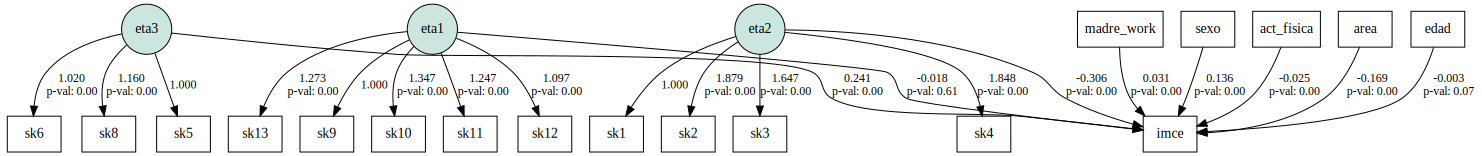

In [299]:
mod = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13       #Exploración Cognitiva y Creativa
eta2 =~ sk1 + sk2 + sk3 + sk4                 #Vinculación Afectiva y Emocional
eta3 =~ sk5 + sk6 + sk8                       #Cooperación y Sociabilidad

imce ~ eta1 + eta2 + eta3 + sexo + edad + act_fisica + area + madre_work 
    """

model = semopy.Model(mod)
out=model.fit(df)
print(out)
print(model.inspect())
semopy.semplot(model, "semmodel.png")

In [300]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,135,158,10095.282742,0.0,87813.333598,0.88637,0.885037,0.865451,0.885037,0.867011,0.049846,71.320091,370.075726,0.339954


# Respuesta 6

Alguno de los hallazgos más relevantes son, exploración cognitiva y creativa (eta1) no tiene un efecto estadisticamente significativo sobre el IMCE, también a su vez, vinculación afectiva y emocional (eta2) representa un efecto negativo y significativo sobre el IMCE, lo que sugoere que se asocia con un menor rendimiento en el imce. Y por último que cooperación y sociabilidad (eta3), tiene un efecto positivo y significativo sobre el IMCE, indicando que mayores niveles de cooperación y sociabilidad se encuentran relacionados con un mejor rendimiento.

En cuanto a las otras variables observadas, sexo tiene un efecto positivo y significativo, sugiriendo que el genero influye en el rendimiento del IMCE, diferente a la edad, que no tiene una significancia tan alta como la de sexo, encontrandose en el umbra. La variable area tiene un efecto negativo y significativo, sugiriendo rendimiento sobre el IMCE según el area de residencia.

EL TLI se encuentra en un 0.867, un valor aceptable para los ajustes, RMSEA esta debajo del 0.05, indicando un buen umbral para un buen ajuste, y por ultimo el CFI indica al igual que el TLI un valor de ajuste razonable. Por lo tanto, el modelo es válido y proporciona información relevante sobre los factores que influyen en el IMCE.



# Pregunta 7
Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?

In [320]:
# Separar datos por clases latentes
df_class0 = df1[df1['pred'] == 0].copy()
df_class1 = df1[df1['pred'] == 1].copy()
df_class2 = df1[df1['pred'] == 2].copy()

# Definir el modelo SEM (misma estructura que en Pregunta 6)
mod = """
# measurement model
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13       #Exploración Cognitiva y Creativa
eta2 =~ sk1 + sk2 + sk3 + sk4                 #Vinculación Afectiva y Emocional
eta3 =~ sk5 + sk6 + sk8                       #Cooperación y Sociabilidad

"""

# Ajustar el modelo para cada clase latente
model_class0 = semopy.Model(mod)
model_class1 = semopy.Model(mod)
model_class2 = semopy.Model(mod)

out0 = model_class0.fit(df_class0)
out1 = model_class1.fit(df_class1)
out2 = model_class2.fit(df_class2)

# Imprimir resultados para cada clase
print("=== CLASE 0 ===")
print(out0)
print(model_class0.inspect())

print("\n=== CLASE 1 ===")
print(out1)
print(model_class1.inspect())

print("\n=== CLASE 2 ===")
print(out2)
print(model_class2.inspect())

# Comparar estadísticos de ajuste
stats0 = semopy.calc_stats(model_class0)
stats1 = semopy.calc_stats(model_class1)
stats2 = semopy.calc_stats(model_class2)

print("\n=== COMPARACIÓN DE AJUSTE ===")
print("Clase 0 - TLI:", stats0["TLI"], "RMSEA:", stats0["RMSEA"])
print("Clase 1 - TLI:", stats1["TLI"], "RMSEA:", stats1["RMSEA"])
print("Clase 2 - TLI:", stats2["TLI"], "RMSEA:", stats2["RMSEA"])

=== CLASE 0 ===
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.194
Number of iterations: 32
Params: 1.234 1.445 1.083 1.089 0.977 1.360 1.629 0.477 0.580 0.197 -0.000 0.118 0.503 -0.013 0.017 0.421 0.764 0.419 0.793 1.110 0.541 0.498 0.418 0.161 0.658 0.703 0.729
    lval  op  rval  Estimate  Std. Err    z-value   p-value
0    sk9   ~  eta1  1.000000         -          -         -
1   sk10   ~  eta1  1.234246  0.065748   18.77232       0.0
2   sk11   ~  eta1  1.444603  0.072694  19.872492       0.0
3   sk12   ~  eta1  1.082970  0.060962  17.764777       0.0
4   sk13   ~  eta1  1.088695  0.066041  16.485063       0.0
5    sk1   ~  eta2  1.000000         -          -         -
6    sk2   ~  eta2  0.976799  0.063288    15.4341       0.0
7    sk3   ~  eta2  1.359812  0.077432  17.561403       0.0
8    sk4   ~  eta2  1.628822  0.093101  17.495269       0.0
9    sk5   ~  eta3  1.000000         -          -   

# Respuesta 7 

Los resultados demuestran que las relaciones entre los factores latentes y el IMCE varían significativamente entre las clases latentes, lo que valida la necesidad de abandonar el supuesto de homogeneidad en los modelos SEM tradicionales.

El modelo si vale la pena por grupos, ya que, revela relaciones no visibles en el agregado y permite intervenciones personalizadas, pero tiene algunas limitaciones tales como, algunas clases (Clase 0) tienen ajuste mediocre o menores al resto de clases.

Algunas ventajas son, descubrimiento de patrones ocultos, personalización de intervenciones y optimización del ajuste.

